<a href="https://colab.research.google.com/github/dtoralg/INESDI_Data-Science_ML_IA/blob/main/%5B05%5D%20-%20Arboles%20de%20decision/02_I_Do_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌲 I Do — Random Forest
### Máster de FP en Business Analytics e Inteligencia Artificial
**Módulo:** Data Analytics: Data Science, Machine Learning e Inteligencia Artificial  
**Profesores:** Daniel Toral García · Álvaro López

---

## 🎯 ¿Qué vamos a aprender hoy?

En este notebook el profesor va a demostrar **paso a paso** cómo construir un modelo de **Random Forest**.

**Problema de negocio:** Una bodega quiere automatizar el control de calidad de sus vinos. En lugar de depender únicamente de catadores humanos (caro y lento), quieren un modelo que, a partir de análisis químicos del vino, prediga si es de **buena o mala calidad**.

**Dataset:** Wine Quality (UCI Machine Learning Repository)  
- 1.599 vinos tintos analizados  
- 11 variables químicas (acidez, azúcar, alcohol, etc.)  
- Puntuación de calidad del 0 al 10 (la convertiremos en bueno/malo)

---

## 📋 Índice
1. Instalación e imports
2. Carga y exploración del dataset
3. Preparación de los datos
4. ¿Qué es un Random Forest? (Concepto visual)
5. Entrenamiento del modelo
6. Evaluación del modelo
7. Importancia de variables
8. Conclusiones de negocio

---
## 📦 1. Instalación e Imports

Primero cargamos todas las librerías que vamos a necesitar.  
En Google Colab todas vienen preinstaladas, no hace falta instalar nada.

In [1]:
# ── Manipulación de datos ──────────────────────────────────────────────────
import pandas as pd          # Para trabajar con tablas (DataFrames)
import numpy as np           # Para operaciones numéricas

# ── Visualización ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt   # Gráficos base
import seaborn as sns             # Gráficos más bonitos y fáciles

# ── Machine Learning (scikit-learn) ───────────────────────────────────────
from sklearn.model_selection import train_test_split   # Dividir datos en train/test
from sklearn.ensemble import RandomForestClassifier    # ← Nuestro modelo principal
from sklearn.metrics import (
    accuracy_score,           # % de aciertos totales
    classification_report,    # Tabla completa de métricas
    confusion_matrix,         # Matriz de confusión
    ConfusionMatrixDisplay     # Para visualizar la matriz
)
from sklearn.tree import export_text                   # Para ver un árbol en texto

# ── Configuración visual ───────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')   # Estilo limpio para los gráficos
sns.set_palette('Set2')                    # Paleta de colores agradable
pd.set_option('display.max_columns', 20)  # Ver todas las columnas en el DataFrame

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 🍷 2. Carga y Exploración del Dataset

Cargamos el dataset directamente desde la URL pública de UCI.  
**No hace falta descargar nada**, pandas puede leer CSVs desde internet.

In [2]:
# Cargamos el dataset de vinos tintos desde el repositorio UCI
# El separador es ';' (punto y coma), no coma
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

print(f'📊 Dataset cargado: {df.shape[0]} vinos | {df.shape[1]} columnas')
print('\n📋 Primeras 5 filas:')
df.head()

📊 Dataset cargado: 1599 vinos | 12 columnas

📋 Primeras 5 filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# ── ¿Qué hay en el dataset? ────────────────────────────────────────────────
print('📌 Información general del dataset:')
print('='*50)
df.info()

# Punto clave: no hay valores nulos → no necesitamos imputación
print(f'\n🔍 Valores nulos por columna:\n{df.isnull().sum()}')

📌 Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

🔍 Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric ac

In [4]:
# ── Estadísticas descriptivas ──────────────────────────────────────────────
# Esto nos da una idea de los rangos de cada variable
print('📈 Estadísticas descriptivas:')
df.describe().round(2)

📈 Estadísticas descriptivas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


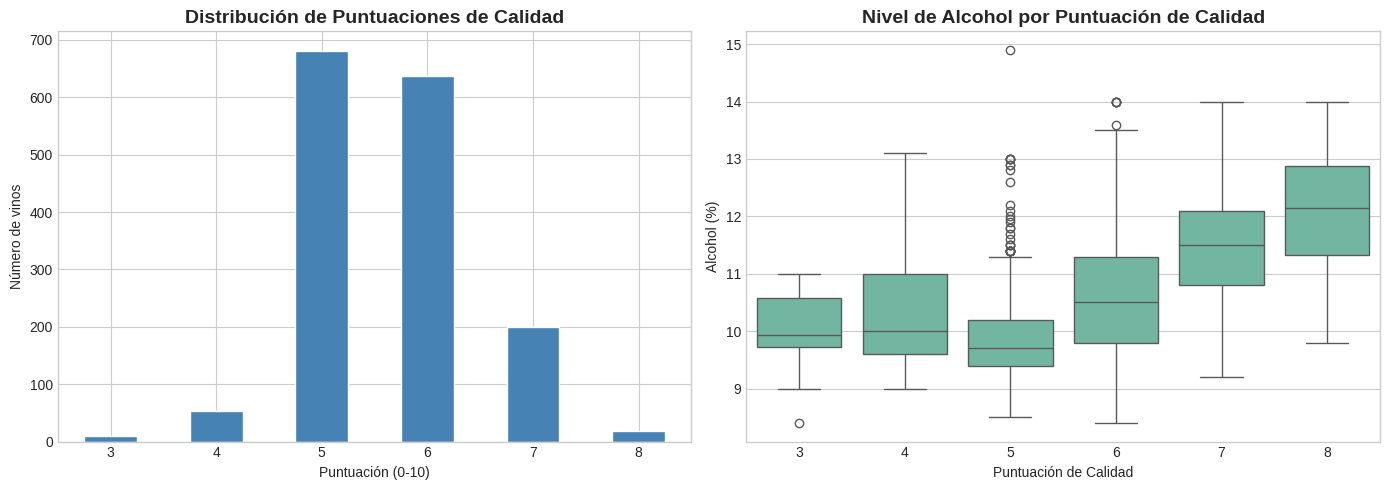

💡 Observación: Los vinos con más alcohol tienden a tener mejor puntuación.
   Esto ya nos da una pista de qué variables serán importantes para el modelo.


In [5]:
# ── Distribución de la variable objetivo (quality) ─────────────────────────
# La puntuación va del 3 al 8 en este dataset (no hay 0,1,2,9,10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: distribución de puntuaciones originales
df['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Distribución de Puntuaciones de Calidad', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Puntuación (0-10)')
axes[0].set_ylabel('Número de vinos')
axes[0].tick_params(rotation=0)

# Gráfico 2: Alcohol vs Calidad → ya vemos una tendencia clara
sns.boxplot(data=df, x='quality', y='alcohol', ax=axes[1])
axes[1].set_title('Nivel de Alcohol por Puntuación de Calidad', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Puntuación de Calidad')
axes[1].set_ylabel('Alcohol (%)')

plt.tight_layout()
plt.show()

print('💡 Observación: Los vinos con más alcohol tienden a tener mejor puntuación.')
print('   Esto ya nos da una pista de qué variables serán importantes para el modelo.')

---
## 🔧 3. Preparación de los Datos

Para que Random Forest pueda aprender, necesitamos:
1. **Definir qué queremos predecir** (variable objetivo / target)
2. **Convertir la puntuación** en un problema binario (bueno/malo)
3. **Separar los datos** en entrenamiento y test

In [6]:
# ── Paso 1: Convertir la puntuación en BINARIO (bueno/malo) ────────────────
# El umbral habitual en la industria: ≥ 7 = vino bueno, < 7 = vino malo
# Esto convierte nuestro problema en CLASIFICACIÓN BINARIA

df['vino_bueno'] = (df['quality'] >= 7).astype(int)

# Comprobamos el balance de clases
conteo = df['vino_bueno'].value_counts()
print('🍷 Distribución de la clase objetivo:')
print(f'  Vino MALO  (0): {conteo[0]} ({conteo[0]/len(df)*100:.1f}%)')
print(f'  Vino BUENO (1): {conteo[1]} ({conteo[1]/len(df)*100:.1f}%)')
print()
print('⚠️  El dataset está desbalanceado (hay muchos más vinos malos que buenos).')
print('   Random Forest maneja esto bien, pero es algo a tener en cuenta.')

🍷 Distribución de la clase objetivo:
  Vino MALO  (0): 1382 (86.4%)
  Vino BUENO (1): 217 (13.6%)

⚠️  El dataset está desbalanceado (hay muchos más vinos malos que buenos).
   Random Forest maneja esto bien, pero es algo a tener en cuenta.


In [7]:
# ── Paso 2: Separar features (X) del target (y) ───────────────────────────
# X = todas las columnas químicas (las que usa el modelo para aprender)
# y = lo que queremos predecir (bueno/malo)

X = df.drop(columns=['quality', 'vino_bueno'])   # Eliminamos las columnas objetivo
y = df['vino_bueno']                              # La variable a predecir

print(f'📐 Dimensiones de X (features): {X.shape}   → {X.shape[0]} filas, {X.shape[1]} columnas')
print(f'📐 Dimensiones de y (target):   {y.shape}   → {y.shape[0]} etiquetas')
print(f'\n📋 Features que usará el modelo:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

📐 Dimensiones de X (features): (1599, 11)   → 1599 filas, 11 columnas
📐 Dimensiones de y (target):   (1599,)   → 1599 etiquetas

📋 Features que usará el modelo:
   1. fixed acidity
   2. volatile acidity
   3. citric acid
   4. residual sugar
   5. chlorides
   6. free sulfur dioxide
   7. total sulfur dioxide
   8. density
   9. pH
  10. sulphates
  11. alcohol


In [8]:
# ── Paso 3: Dividir en Train (entrenamiento) y Test (evaluación) ──────────
# train_test_split separa aleatoriamente los datos
# test_size=0.2  → 20% para test, 80% para entrenar
# random_state=42 → fija la semilla aleatoria para que todos obtengamos los mismos resultados
# stratify=y     → mantiene la misma proporción de bueno/malo en train y test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Muy importante con clases desbalanceadas
)

print('✂️  División de datos:')
print(f'  🔵 Entrenamiento: {X_train.shape[0]} vinos ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'  🔴 Test:          {X_test.shape[0]}  vinos ({X_test.shape[0]/len(df)*100:.0f}%)')
print()
print('💡 Regla general: 80% train / 20% test es el estándar para datasets medianos.')
print('   Con datasets muy pequeños (<500 filas) se suele usar 70/30 o validación cruzada.')

✂️  División de datos:
  🔵 Entrenamiento: 1279 vinos (80%)
  🔴 Test:          320  vinos (20%)

💡 Regla general: 80% train / 20% test es el estándar para datasets medianos.
   Con datasets muy pequeños (<500 filas) se suele usar 70/30 o validación cruzada.


---
## 🌳 4. ¿Qué es un Random Forest? (Concepto)

Antes de entrenar, entendamos **qué hace el algoritmo**:

```
                    DATASET COMPLETO
                    (1.279 vinos)
                         │
          ┌──────────────┼──────────────┐
          │              │              │
     Muestra 1      Muestra 2      Muestra N
     (aleatoria)   (aleatoria)    (aleatoria)   ← Bagging
          │              │              │
     Árbol 1       Árbol 2        Árbol N      ← Cada árbol ve
     (alcohol,     (acidez,       (azúcar,        columnas aleatorias
      acidez)       sulfatos)      alcohol)
          │              │              │
     MALO ✗        BUENO ✓       MALO ✗
          │              │              │
          └──────────────┼──────────────┘
                   VOTACIÓN (2 MALO vs 1 BUENO)
                         │
                    PREDICCIÓN: MALO
```

**Las 3 ideas clave:**
1. **Muchos árboles** → cada árbol aprende algo distinto
2. **Aleatoriedad doble** → datos aleatorios + columnas aleatorias en cada árbol
3. **Votación** → la mayoría decide (clasificación) o promedio (regresión)

**¿Por qué es mejor que un solo árbol?**  
Un árbol solo puede sobreajustarse (memoriza el training). Con 100 árboles, los errores individuales se cancelan entre sí.

---
## 🚀 5. Entrenamiento del Modelo

Con scikit-learn, entrenar un Random Forest son **3 líneas de código**.

In [9]:
# ── Creamos el modelo ──────────────────────────────────────────────────────
# Parámetros más importantes (no hay que memorizar todos, solo entender los básicos):
#
# n_estimators=100   → número de árboles en el bosque (más = más robusto, pero más lento)
#                      100 es un buen punto de partida
#
# max_depth=5        → profundidad máxima de cada árbol
#                      Sin límite: los árboles se hacen enormes y se sobreajustan
#                      Con límite: árboles más simples y generalizables
#
# random_state=42    → para reproducibilidad (siempre mismo resultado)
#
# class_weight='balanced' → ajusta automáticamente el peso de las clases
#                            MUY ÚTIL cuando hay desbalance (pocos vinos buenos)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'   # Compensa el desbalance bueno/malo
)

print('🌲 Modelo Random Forest creado con los siguientes parámetros:')
print(f'   - Número de árboles: {rf_model.n_estimators}')
print(f'   - Profundidad máxima: {rf_model.max_depth}')
print(f'   - Peso de clases: {rf_model.class_weight}')

🌲 Modelo Random Forest creado con los siguientes parámetros:
   - Número de árboles: 100
   - Profundidad máxima: 5
   - Peso de clases: balanced


In [10]:
# ── Entrenamos el modelo ───────────────────────────────────────────────────
# .fit() es donde ocurre el aprendizaje
# El modelo ve X_train e y_train y aprende los patrones

rf_model.fit(X_train, y_train)

print('✅ Modelo entrenado correctamente')
print(f'   Ha construido {rf_model.n_estimators} árboles de decisión')
print(f'   Cada árbol considera √{X_train.shape[1]} ≈ {rf_model.max_features} features por split')

✅ Modelo entrenado correctamente
   Ha construido 100 árboles de decisión
   Cada árbol considera √11 ≈ sqrt features por split


In [11]:
# ── Hacemos predicciones sobre los datos de test ───────────────────────────
# IMPORTANTE: el modelo NUNCA ha visto X_test durante el entrenamiento
# Esto garantiza que la evaluación sea honesta

y_pred = rf_model.predict(X_test)                  # Clase predicha (0 o 1)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Probabilidad de ser 'bueno' (clase 1)

print('🔮 Predicciones realizadas sobre el conjunto de test')
print(f'   Ejemplo de predicciones: {y_pred[:10]}')
print(f'   Ejemplo de probabilidades: {y_pred_proba[:10].round(2)}')
print()
print('💡 La probabilidad nos da más información que la clase sola.')
print('   Un vino con prob=0.90 es muy probablemente bueno.')
print('   Un vino con prob=0.52 es más incierto (casi en el límite).')

🔮 Predicciones realizadas sobre el conjunto de test
   Ejemplo de predicciones: [0 0 0 0 0 1 0 0 0 0]
   Ejemplo de probabilidades: [0.39 0.1  0.08 0.1  0.03 0.68 0.35 0.18 0.04 0.12]

💡 La probabilidad nos da más información que la clase sola.
   Un vino con prob=0.90 es muy probablemente bueno.
   Un vino con prob=0.52 es más incierto (casi en el límite).


---
## 📊 6. Evaluación del Modelo

Hay varias métricas para medir qué tan bien funciona el modelo.  
Cada una mide algo diferente y es más útil según el problema de negocio.

In [12]:
# ── Accuracy (exactitud) ──────────────────────────────────────────────────
# % de predicciones correctas sobre el total
# Fórmula: aciertos / total

acc_train = accuracy_score(y_train, rf_model.predict(X_train))
acc_test  = accuracy_score(y_test,  y_pred)

print('🎯 Accuracy del modelo:')
print(f'   Training: {acc_train:.3f} ({acc_train*100:.1f}%)')
print(f'   Test:     {acc_test:.3f}  ({acc_test*100:.1f}%)')
print()

# Interpretación del gap train/test
gap = acc_train - acc_test
if gap < 0.05:
    print('✅ Gap pequeño (< 5%): el modelo generaliza bien, no hay sobreajuste.')
elif gap < 0.10:
    print('⚠️  Gap moderado (5-10%): ligero sobreajuste, revisar max_depth o n_estimators.')
else:
    print('❌ Gap grande (> 10%): sobreajuste significativo, simplificar el modelo.')

🎯 Accuracy del modelo:
   Training: 0.876 (87.6%)
   Test:     0.884  (88.4%)

✅ Gap pequeño (< 5%): el modelo generaliza bien, no hay sobreajuste.


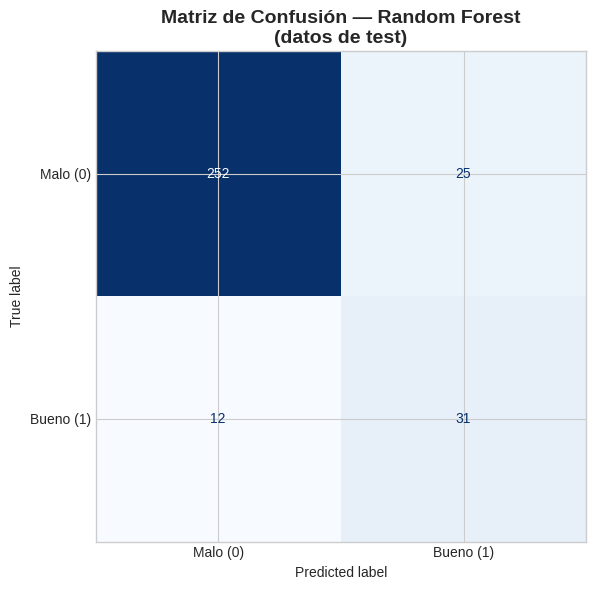

📊 Desglose de resultados en test (320 vinos):
   ✅ Verdaderos Negativos (TN): 252  → predijo MALO  y era MALO
   ✅ Verdaderos Positivos (TP):  31  → predijo BUENO y era BUENO
   ❌ Falsos Positivos    (FP):  25  → predijo BUENO y era MALO  (vendimos vino mediocre como premium)
   ❌ Falsos Negativos    (FN):  12  → predijo MALO  y era BUENO (rechazamos un buen vino)


In [13]:
# ── Matriz de Confusión ────────────────────────────────────────────────────
# La matriz de confusión nos dice QUÉ TIPO de errores comete el modelo
#
#                  PREDICCIÓN
#              Malo(0)  │  Bueno(1)
#         ─────────────────────────
#  REAL   Malo(0)   TN  │   FP
#         ─────────────────────────
#         Bueno(1)  FN  │   TP
#
# TN = True Negative  → dijimos malo  y era malo  ✅
# TP = True Positive  → dijimos bueno y era bueno ✅
# FP = False Positive → dijimos bueno y era malo  ❌ (error tipo I)
# FN = False Negative → dijimos malo  y era bueno ❌ (error tipo II)

fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Malo (0)', 'Bueno (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Matriz de Confusión — Random Forest\n(datos de test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'📊 Desglose de resultados en test ({len(y_test)} vinos):')
print(f'   ✅ Verdaderos Negativos (TN): {tn:3d}  → predijo MALO  y era MALO')
print(f'   ✅ Verdaderos Positivos (TP): {tp:3d}  → predijo BUENO y era BUENO')
print(f'   ❌ Falsos Positivos    (FP): {fp:3d}  → predijo BUENO y era MALO  (vendimos vino mediocre como premium)')
print(f'   ❌ Falsos Negativos    (FN): {fn:3d}  → predijo MALO  y era BUENO (rechazamos un buen vino)')

In [14]:
# ── Classification Report: Precision, Recall y F1-Score ───────────────────
#
# PRECISION  = De todos los que predije BUENO, ¿cuántos realmente lo eran?
#              → Evitar vender vino malo como bueno (cara al cliente)
#
# RECALL     = De todos los BUENOS reales, ¿cuántos capturé?
#              → Evitar rechazar vinos buenos (pérdida de producto)
#
# F1-SCORE   = Media armónica de Precision y Recall
#              → Balance entre los dos. Mejor métrica con clases desbalanceadas

print('📋 Classification Report completo:')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Malo (0)', 'Bueno (1)']))
print()
print('💡 Interpretación para la bodega:')
print('   Si precision_bueno es alta → podemos confiar cuando el modelo dice "bueno"')
print('   Si recall_bueno es alta    → el modelo no se pierde vinos buenos')

📋 Classification Report completo:
              precision    recall  f1-score   support

    Malo (0)       0.95      0.91      0.93       277
   Bueno (1)       0.55      0.72      0.63        43

    accuracy                           0.88       320
   macro avg       0.75      0.82      0.78       320
weighted avg       0.90      0.88      0.89       320


💡 Interpretación para la bodega:
   Si precision_bueno es alta → podemos confiar cuando el modelo dice "bueno"
   Si recall_bueno es alta    → el modelo no se pierde vinos buenos


---
## 🔍 7. Importancia de Variables (Feature Importance)

Una de las grandes ventajas de Random Forest es que nos dice **qué variables son más importantes** para hacer predicciones. Esto es oro para el negocio.

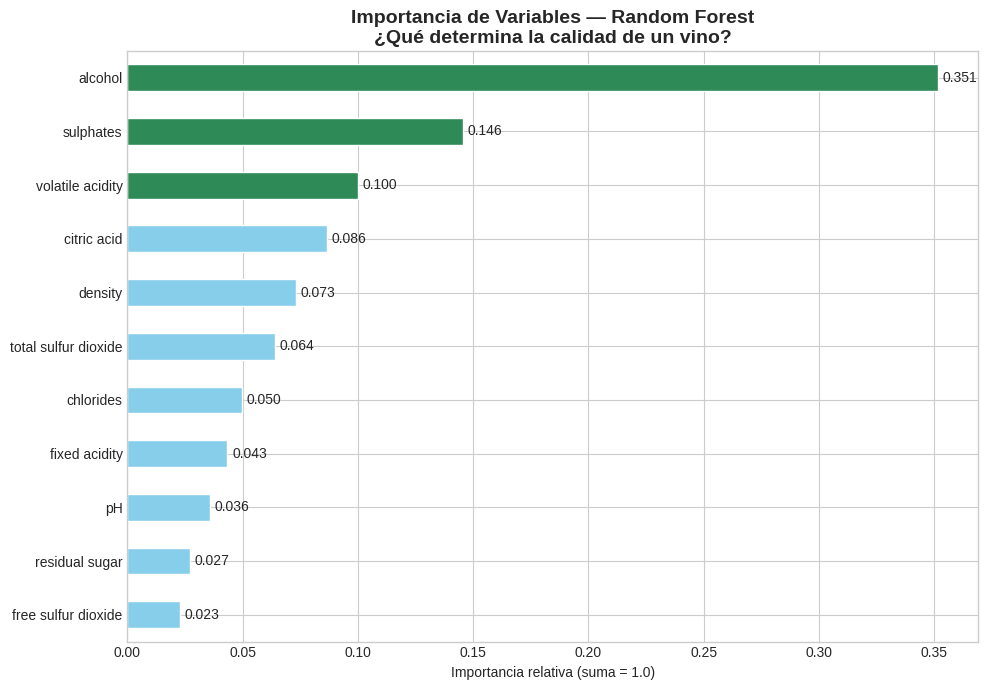

🏆 Top 3 variables más importantes:
   1. alcohol                        → 35.1% de importancia
   2. sulphates                      → 14.6% de importancia
   3. volatile acidity               → 10.0% de importancia


In [15]:
# ── Extraemos la importancia de cada variable ──────────────────────────────
# .feature_importances_ devuelve un array con la importancia relativa de cada feature
# Los valores suman 1.0 (es un porcentaje de "contribución al modelo")

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)  # ascending=True para que el más importante salga arriba en el plot

# ── Visualización ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# Coloreamos las top 3 features en verde oscuro para destacarlas
colors = ['#2E8B57' if i >= len(importances) - 3 else '#87CEEB'
          for i in range(len(importances))]

importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Importancia de Variables — Random Forest\n¿Qué determina la calidad de un vino?',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia relativa (suma = 1.0)')
ax.set_ylabel('')

# Añadimos los valores numéricos al final de cada barra
for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('🏆 Top 3 variables más importantes:')
top3 = importances.sort_values(ascending=False).head(3)
for i, (feat, imp) in enumerate(top3.items(), 1):
    print(f'   {i}. {feat:<30} → {imp*100:.1f}% de importancia')

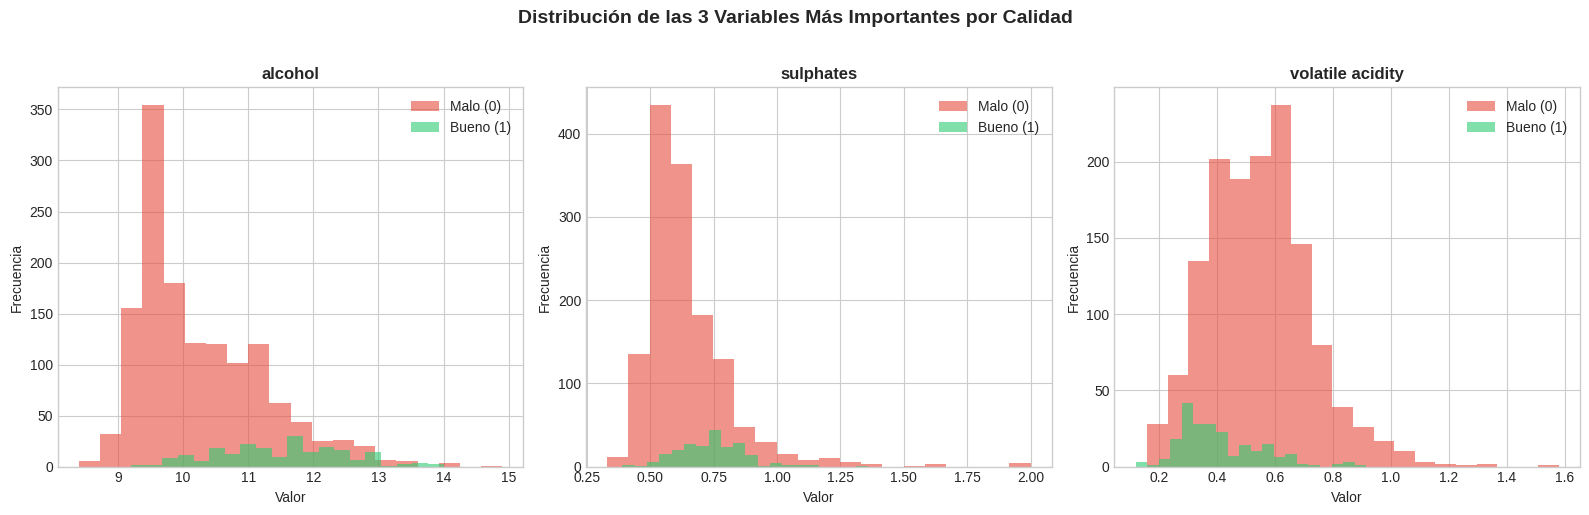

💡 Si los histogramas de bueno y malo se solapan poco → la variable es muy discriminativa
   Si se solapan mucho → la variable aporta menos información al modelo


In [16]:
# ── Análisis de las variables top ─────────────────────────────────────────
# Veamos cómo se distribuyen las top 3 variables entre vinos buenos y malos

top3_features = importances.sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, top3_features):
    # Separamos los valores por clase
    malo  = df[df['vino_bueno'] == 0][feature]
    bueno = df[df['vino_bueno'] == 1][feature]

    ax.hist(malo,  bins=20, alpha=0.6, label='Malo (0)',  color='#E74C3C')
    ax.hist(bueno, bins=20, alpha=0.6, label='Bueno (1)', color='#2ECC71')
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.suptitle('Distribución de las 3 Variables Más Importantes por Calidad',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Si los histogramas de bueno y malo se solapan poco → la variable es muy discriminativa')
print('   Si se solapan mucho → la variable aporta menos información al modelo')

---
## 🏁 8. Conclusiones de Negocio

Cerramos siempre con **¿qué significa esto para la empresa?**

In [17]:
# ── Resumen ejecutivo ──────────────────────────────────────────────────────
print('='*65)
print('  📋 RESUMEN EJECUTIVO — MODELO DE CALIDAD DE VINO')
print('='*65)
print()
print(f'  📊 Dataset analizado:    {len(df):,} vinos tintos')
print(f'  🎯 Exactitud del modelo: {acc_test*100:.1f}% en datos no vistos')
print()
print('  🔑 Variables clave identificadas:')
for i, (feat, imp) in enumerate(importances.sort_values(ascending=False).head(3).items(), 1):
    print(f'     {i}. {feat:<30} ({imp*100:.1f}%)')
print()
print('  💼 Aplicación práctica para la bodega:')
print()
print('  1. CONTROL DE CALIDAD AUTOMATIZADO')
print('     → Analizar las 11 variables químicas es rápido y barato')
print('     → El modelo puede pre-filtrar vinos antes de la cata humana')
print()
print('  2. OPTIMIZACIÓN DE PRODUCCIÓN')
print('     → Conocer qué variables predicen calidad permite ajustar')
print('       los procesos de fermentación y elaboración')
print()
print('  3. ESCALABILIDAD')
print('     → El modelo puede procesar miles de muestras/hora')
print('     → Un catador humano no puede hacer eso')
print()
print('  ⚠️  Limitaciones del modelo actual:')
print('     - Entrenado solo con vinos tintos (no aplica a blancos directamente)')
print('     - Dataset de una región/bodega específica')
print('     - La calidad subjetiva humana puede diferir del umbral ≥7')

  📋 RESUMEN EJECUTIVO — MODELO DE CALIDAD DE VINO

  📊 Dataset analizado:    1,599 vinos tintos
  🎯 Exactitud del modelo: 88.4% en datos no vistos

  🔑 Variables clave identificadas:
     1. alcohol                        (35.1%)
     2. sulphates                      (14.6%)
     3. volatile acidity               (10.0%)

  💼 Aplicación práctica para la bodega:

  1. CONTROL DE CALIDAD AUTOMATIZADO
     → Analizar las 11 variables químicas es rápido y barato
     → El modelo puede pre-filtrar vinos antes de la cata humana

  2. OPTIMIZACIÓN DE PRODUCCIÓN
     → Conocer qué variables predicen calidad permite ajustar
       los procesos de fermentación y elaboración

  3. ESCALABILIDAD
     → El modelo puede procesar miles de muestras/hora
     → Un catador humano no puede hacer eso

  ⚠️  Limitaciones del modelo actual:
     - Entrenado solo con vinos tintos (no aplica a blancos directamente)
     - Dataset de una región/bodega específica
     - La calidad subjetiva humana puede diferi

In [18]:
# ── Bonus: Predecir un vino nuevo ─────────────────────────────────────────
# Así es como se usaría el modelo en producción
# Un técnico de laboratorio introduce los valores del análisis químico
# y el modelo devuelve la predicción instantáneamente

# Vino hipotético: alto alcohol, acidez volcátil baja (típico de vinos buenos)
nuevo_vino = pd.DataFrame([{
    'fixed acidity':       7.4,
    'volatile acidity':    0.30,   # ← bajo: buena señal
    'citric acid':         0.34,
    'residual sugar':      2.1,
    'chlorides':           0.075,
    'free sulfur dioxide': 17.0,
    'total sulfur dioxide':60.0,
    'density':             0.998,
    'pH':                  3.30,
    'sulphates':           0.56,
    'alcohol':             11.8    # ← alto: buena señal
}])

prediccion  = rf_model.predict(nuevo_vino)[0]
probabilidad = rf_model.predict_proba(nuevo_vino)[0, 1]

print('🍷 Análisis de un vino nuevo:')
print(f'   Alcohol:          {nuevo_vino["alcohol"].values[0]}%')
print(f'   Acidez volátil:   {nuevo_vino["volatile acidity"].values[0]}')
print()
print(f'   ➜ Predicción:     {"BUENO ✅" if prediccion == 1 else "MALO ❌"}')
print(f'   ➜ Confianza:      {probabilidad*100:.1f}% de probabilidad de ser BUENO')
print()
print('💡 En producción, este código se integraría en una API o dashboard.')
print('   El técnico introduce los datos y obtiene la respuesta en milisegundos.')

🍷 Análisis de un vino nuevo:
   Alcohol:          11.8%
   Acidez volátil:   0.3

   ➜ Predicción:     MALO ❌
   ➜ Confianza:      35.7% de probabilidad de ser BUENO

💡 En producción, este código se integraría en una API o dashboard.
   El técnico introduce los datos y obtiene la respuesta en milisegundos.


---

## 📌 Resumen de conceptos vistos

| Concepto | Qué es | Para qué sirve |
|---|---|---|
| `train_test_split` | Divide datos en train/test | Evaluar el modelo de forma honesta |
| `RandomForestClassifier` | Ensemble de árboles con votación | Clasificar con alta robustez |
| `n_estimators` | Número de árboles | Más árboles = más robusto (pero más lento) |
| `max_depth` | Profundidad máxima de cada árbol | Controla el sobreajuste |
| `class_weight='balanced'` | Ajuste de pesos por clase | Compensar clases desbalanceadas |
| `accuracy_score` | % de aciertos totales | Métrica general del modelo |
| Matriz de confusión | Tabla de errores por tipo | Entender qué errores comete el modelo |
| `feature_importances_` | Relevancia de cada variable | Explicabilidad e insights de negocio |